# 第9课 · 每一帧声音都是一支箭——向量（vector）加法、缩放与线性组合（linear combination）

**学习目标**
1. 理解向量是 shape `(n,)` 的 NumPy array，`.shape` 和 `.dtype` 是必检属性
2. 掌握向量加法（混音）和标量缩放（调音量）的代数与几何含义
3. 实现 `scale(v, c)` 函数，通过单元测试验证标量乘法
4. 会算向量长度（勾股定理 / `np.linalg.norm`），知道一帧 MFCC 是 13 维向量
5. 理解线性组合：任意 2D 向量可由基向量 `e1`, `e2` 加权叠加表示

**为什么对 Aurora 重要**：Aurora 的 MFCC 特征提取把每帧音频压缩成一个 `(13,)` 向量；`scale(v, c)` 调音量时就是对这个向量做标量缩放（scalar scaling）。神经网络每层的激活值同样是向量。

← **上一课**　[L08 · 复数平面可视化](../1_complex_trig/L08_visual_complex.ipynb)

> 上节课学习了 **复数平面可视化**：单位圆旋转、共轭与相位，matplotlib 动态演示。  
> 本课将探讨 **向量代数**。

## 本课剧情：一串数字，藏着方向和大小

你在混音台前，推一个推子——声音变大了。用数学说：每一个采样值乘以同一个系数，这就是**标量乘法**（scalar multiplication）。

再叠加两轨音频——男声和女声同时响。用数学说：两个等长数组逐元素相加，这就是**向量加法**（vector addition）。

向量的全部基本操作就是这两件事——**本课只练这两块砖**：加法和缩放（再拼出线性组合）。

线代大厦的地基是向量。矩阵、特征方向、SVD 会在后面的课出现；今天不必一次装完整栋楼。

本课先写好：`scale`、`add_signals`，再用它们拼出 `linear_combination`。

## 1. 向量就是 numpy 数组

有没有想过：为什么线性代数用到 NumPy？

因为 NumPy 的一维 array 就是向量——一个**有顺序的数列** `[x₁, x₂, …, xₙ]`，形状（shape）是 `(n,)`。

物理上，向量是"带方向的箭头"：
- 二维向量 `[3, 4]` → 从原点出发，向右 3、向上 4 的箭头，长度 5
- 音频信号 `[0.1, -0.3, 0.5, ...]` → N 维空间里的一个点（或一条路径）

音频处理中向量无处不在：
- 一帧 MFCC 系数 = 13 维向量（特征空间里的一个点）
- 后面会遇到的高维特征（比如很长一串数字表示的"语义向量"）= 规则完全一样，只是分量更多
- 两帧音频之间的相似度 = 向量点积

**关键直觉**：`shape = (n,)` 是向量，`shape = (m, n)` 是矩阵（多个向量排列）。把 shape 读清楚，不会在矩阵乘法时迷路。

### 先别急着抽象：箭头是怎么变成数组的？

高中学的向量，是从原点出发、指向平面上某一点的"箭头"——比如"从家往东走 3 格、往北走 4 格"，这支箭头就画出来了。但 Aurora 里向量是一串数字 `[0.1, -0.3, 0.5, ...]`，看起来完全不像箭头。这两者到底是不是一回事？

**关键洞察**：箭头之所以能画出来，正是因为我们用"往右 3 格、往上 4 格"这样一组数字描述了它——`(3, 4)` 这组数字本身，就是箭头的全部信息。画出箭头只是把这组数字在纸上"翻译"成图形的一种方式，**数字本身才是向量的本体**，箭头只是它在 2D、3D 时的一种可视化。

**音频信号呢**：`[0.1, -0.3, 0.5, ...]` 是 5 个数字，代数上对应一个 5 维空间里的"箭头"——从原点指向坐标 `(0.1, -0.3, 0.5, ...)` 的点。我们没法在纸上画出 5 维箭头，但它遵循和 2D 箭头完全一样的规则：加法逐位相加，缩放逐位相乘。

**"点"还是"箭头"，该用哪个？** 同一个数组，既可以看成"终点是这个坐标的点"，也可以看成"从原点出发到这个点的箭头"——两种说法描述的是同一个数学对象。箭头强调"方向/位移"，点强调"位置"。工程上不用纠结用哪个词：MFCC 向量你叫它"特征空间里的一个点"或"一支箭头"都对，选哪个只看你想强调"在哪"还是"指向哪"。

**维度一高，别指望画图**：一旦维度超过 3，人脑就画不出箭头了，这完全没关系——向量的两个基本操作（加法、缩放）从来不依赖"能不能画出来"，它们的定义就是**逐分量操作**。13 维的 MFCC 向量，你不需要在脑子里硬想象一个 13 维空间，只需要记住："向量运算 = 对列表里每个数字独立做同样的算术"。这也是为什么 NumPy 处理 3 维和 300 维向量的代码写法完全一样——下面会用一个 5 维例子直接验证这件事。

## 符号入口：先看形状，再看运算

线性代数里的对象都有明确形状：向量是 `(n,)`，矩阵是 `(m, n)`，矩阵乘向量会把 `(n,)` 变成 `(m,)`。每个例子都先标出输入、变换和输出。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
v = np.array([3.0, 4.0])      # 2 维向量
audio = np.array([0.0, 0.5, 1.0, 0.5, 0.0])  # 5 个采样点 = 5 维向量
print('v =', v, '| 维度:', v.shape)
print('audio 是一个', audio.shape[0], '维向量')

v = [3. 4.] | 维度: (2,)
audio 是一个 5 维向量


## 动手观察：shape 和 norm

观察 `v.shape` 输出 `(2,)`、`A.shape` 输出 `(2, 2)`、`A @ v` 的结果——矩阵把向量拉伸后 shape 不变但值变了。`np.linalg.norm(v)` 返回 5.0，即 √(3²+4²)，这是向量长度的 NumPy 写法。

In [3]:
import numpy as np

v = np.array([3.0, 4.0])
A = np.array([[2.0, 0.0],
              [0.0, 0.5]])

print('v =', v, 'shape =', v.shape)
print('A =')
print(A)
print('A shape =', A.shape)
print('A @ v =', A @ v)
print('向量长度 ||v|| =', np.linalg.norm(v))


v = [3. 4.] shape = (2,)
A =
[[2.  0. ]
 [0.  0.5]]
A shape = (2, 2)
A @ v = [6. 2.]
向量长度 ||v|| = 5.0


### 加个注脚：`‖v‖` 这个符号哪来的？公式又是哪来的？

先说个生活场景：你在操场上，向东走 3 米，再向北走 4 米。现在问，你离出发点的直线距离是多少？画个图就知道——这是一个直角三角形，两条直角边分别是 3 和 4，你要求的是斜边。初中学过的勾股定理告诉你：斜边² = 3² + 4² = 25，斜边 = 5。

**这正是向量长度公式的来源**：向量 `[3, 4]` 的"长度"，就是从原点直线走到 `(3, 4)` 这个点的距离，而这个距离恰好是勾股定理里的斜边。所以公式 `‖v‖ = √(v₁² + v₂²)` 不是凭空规定的，它就是勾股定理换了个写法——把"两条直角边"换成"向量的两个分量"。分量是负数（比如 `[3, -4]`）也不影响，因为公式里分量都先平方，负号被抹掉了，几何上"走了 4 米"和"往哪个方向走了 4 米"不影响距离本身。

**为什么符号要用双竖线 `‖v‖`，而不是绝对值的单竖线 `|x|`？** 因为向量比标量多了"很多个分量"，双竖线提醒你：这里量的是整个向量的"整体大小"，不是某一个数字的绝对值。这个量"整体大小"的工具，数学上统称为**范数**（norm）——这个词来自拉丁语 *norma*，本意是"标准、尺子"，范数就是一把用来衡量向量有多大的尺子。

**那这把尺子只有一种量法吗？** 不是。`√(v₁² + v₂²)`（先平方、求和、开根号）是最常用的一种，叫 **L2 范数**，对应你熟悉的"直线距离"（欧式距离）。还有一种更朴素的量法：直接把各分量的绝对值加起来，`|v₁| + |v₂|`，叫 **L1 范数**，对应"出租车距离"（曼哈顿距离）——想象一个方格状的城市，出租车不能抄对角线近路，只能沿着街道走,走过的总路程就是 L1 范数。两种"尺子"都合法，只是关心的东西不同：L2 关心两点间的直线距离，L1 关心"沿坐标轴走"的总路程，对个别分量突然变得很大（异常值）也没那么敏感。`np.linalg.norm(v)` 默认算 L2，传 `ord=1` 就能换成 L1——下面直接跑一下对比。


In [4]:
v = np.array([3.0, 4.0])
l2 = np.linalg.norm(v)          # 默认 ord=2：欧式距离（直线距离）
l1 = np.linalg.norm(v, ord=1)   # ord=1：绝对值之和（出租车距离）
print(f'L2 范数 ‖v‖₂ = √(3²+4²)   = {l2}')
print(f'L1 范数 ‖v‖₁ = |3| + |4|  = {l1}')


L2 范数 ‖v‖₂ = √(3²+4²)   = 5.0
L1 范数 ‖v‖₁ = |3| + |4|  = 7.0


## 代码实验：任意向量都是基向量的线性组合

下面的代码展示**任意 2D 向量都是基向量 e₁、e₂ 的线性组合**：给定系数 (a, b)，输出向量就是 `a·e₁ + b·e₂`。这是线性组合（linear combination）最直接的几何含义——方向和长度由系数决定，基向量提供"坐标轴"。

> **注**：矩阵对向量的作用将在 L12（矩阵）中详细展开。

In [5]:
import numpy as np

# 线性组合：3 个基向量用不同系数叠加
e1 = np.array([1.0, 0.0]); e2 = np.array([0.0, 1.0])
for a, b in [(1,0), (0,1), (2,-1), (0.5, 1.5)]:
    v = a*e1 + b*e2
    print(f'{a}*e1 + {b}*e2 = {v}')
print('→ 任意 2D 向量 = 系数1*e1 + 系数2*e2')


1*e1 + 0*e2 = [1. 0.]
0*e1 + 1*e2 = [0. 1.]
2*e1 + -1*e2 = [ 2. -1.]
0.5*e1 + 1.5*e2 = [0.5 1.5]
→ 任意 2D 向量 = 系数1*e1 + 系数2*e2


### 追问一步：凭什么"任意向量都行"？换一组基向量行不行？

上面的代码只是"试了几个例子都成功了"，这不等于证明。换个角度想：你给朋友指路，"往东走几条街、往北走几条街"就能到城里任何一个路口——前提是"正东"和"正北"这两个方向必须**互相独立**：往东走多远，都不会顺带让你往北挪一点。这种"谁都不能由别人凑出来"的关系，数学上叫**线性无关**（linearly independent）。凡是能满足"用它们的线性组合可以走到平面上任意一点"的一组方向，就叫一组**基**（basis）。`e1=[1,0]`、`e2=[0,1]` 只是最方便的一组基，不是唯一的一组。

**为什么 2D 平面恰好需要 2 个基向量，不多不少？** 因为"2 维"这个说法本身，指的就是"恰好需要 2 个互相独立的方向，才能走到平面上任意一点"。如果只给 1 个方向，你只能沿着一条直线走，走不到线外的点；如果给 3 个方向，其中必然有一个可以被另外两个的线性组合表示出来（不独立，属于多余）。维度数 = 最少需要的独立方向数，这不是巧合，是"维度"这个词的定义方式。

**换成别的向量当基，行不行？** 只要两个向量不平行（不在同一条直线上），它们就依然独立，依然可以当基——下面用 `f1=[1,1]`、`f2=[1,-1]` 试着表示同一个目标向量，看是否也能凑出来。反过来，如果两个向量互相平行（比如 `[1,1]` 和 `[2,2]`，后者就是前者的 2 倍），那它们只能覆盖一条直线，平面上绝大多数点都够不着——这时候"基"就失败了，专业说法是这两个向量**线性相关**（linearly dependent）。下面的代码把这两种情况都跑一遍。


In [6]:
target = np.array([3.0, 4.0])

# 换一组基：f1, f2 不平行 -> 依然是一组合法的基
f1 = np.array([1.0, 1.0]); f2 = np.array([1.0, -1.0])
basis_matrix = np.column_stack([f1, f2])          # 两列分别是 f1, f2
a, b = np.linalg.solve(basis_matrix, target)      # 解出系数 a, b 使 a*f1 + b*f2 = target
print(f'{a}*f1 + {b}*f2 = {a*f1 + b*f2}  (目标是 {target})')

# 反例：g1, g2 互相平行（g2 = 2*g1），线性相关，基失效
g1 = np.array([1.0, 1.0]); g2 = np.array([2.0, 2.0])
try:
    bad_basis = np.column_stack([g1, g2])
    np.linalg.solve(bad_basis, target)
except np.linalg.LinAlgError as e:
    print(f'g1, g2 互相平行，无法作为基：{e}')


3.5*f1 + -0.5*f2 = [3. 4.]  (目标是 [3. 4.])
g1, g2 互相平行，无法作为基：Singular matrix


## 2. 加法 = 逐元素相加；缩放 = 每个元素乘同一个数

In [7]:
a = np.array([1.0, 2.0])
b = np.array([3.0, 1.0])
print('a + b =', a + b)     # 信号叠加（混音）就是向量加法
print('2 * a =', 2 * a)     # 放大 2 倍 = 标量缩放

a + b = [4. 3.]
2 * a = [2. 4.]


## 3. ✏️ 你的任务：实现 `scale`

`scale(v, c)` 把向量 `v` 的每个分量都乘以标量 `c`——这是音量旋钮的数学本质。

**推理路线**：
1. 标量缩放的几何意义：向量方向不变，长度变为原来的 `|c|` 倍；当 `c < 0` 时方向反转，`c = 0` 时变成零向量。
2. NumPy 广播：`c * v` 把标量 `c` 自动应用到 `v` 的每个元素——无需写 for 循环，底层是 SIMD 并行指令。
3. 返回 shape：`c * v` 的 shape 与 `v` 完全相同，不需要额外 reshape。

**参考输入输出**：`scale([1.0, 2.0], 2.0)` → `[2.0, 4.0]`；`scale([0.2, -0.4], 1.5)` → `[0.3, -0.6]`

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### `c < 0` 时"方向反转"，在 13 维的 MFCC 向量上是什么意思？

2D 向量 `[3, 4]` 乘 `-1` 得到 `[-3, -4]`，画在纸上一看就懂：箭头转了 180 度，指向反方向。但 Aurora 里 `scale(frame, -1)` 作用在 13 维的 MFCC 向量上，13 个数字全部变号——这时候没有纸能画出这支"箭头"，"反向"还有意义吗？

**有，但它已经是纯代数意义，不再依赖"能不能画出来"。** "方向相反"这件事，最核心的性质其实不是"箭头转了180度"这幅画面，而是两条可以直接用数字验证的性质：
1. 大小不变——`‖v‖ = ‖-v‖`，反转前后长度一样；
2. 首尾相消——`v + (-v)` 正好是全零向量，两者"完全抵消"。

这两条性质只涉及逐分量的加法和取负，2D、3D、13 维、300 维都一样成立，不需要"画得出来"才算数。所以高维空间里的"方向"，你可以把它理解成：抽象的代数结构原封不动地保留了下来,只是配套的那幅"箭头图"没了。下节课的点积（dot product）会给你一个更强的工具——即使完全想象不出画面，也能算出任意两个高维向量之间的"夹角"，到时"方向"这个词会变得更精确、也更可计算。

现在只需要记住一句话：13 维的 `scale(frame, -1)`，效果就是让 13 个数字各自变号——在音频工程里，这等价于"信号反相"（phase inversion），常见于降噪中的反相抵消。下面直接验证一下上面两条性质在 13 维向量上依然成立。


In [8]:
frame = np.array([0.2, -0.1, 0.05, 0.3, -0.2, 0.1, 0.0, 0.15, -0.05, 0.2, -0.1, 0.05, 0.1])  # 模拟一帧 13 维 MFCC
flipped = -1 * frame  # 等价于 scale(frame, -1)：13 个分量各自变号

print('原始长度  ‖frame‖   =', np.linalg.norm(frame))
print('反转后长度 ‖flipped‖ =', np.linalg.norm(flipped), '  (大小不变)')
print('frame + flipped     =', frame + flipped, '  (首尾相消，全零向量)')


原始长度  ‖frame‖   = 0.5291502622129182
反转后长度 ‖flipped‖ = 0.5291502622129182   (大小不变)
frame + flipped     = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]   (首尾相消，全零向量)


### 写 `scale` 前明确三件事

- 输入：`v`（numpy array，任意 shape）；`c`（浮点数，缩放系数）
- 关键步骤：`c * v`，NumPy 的标量乘法对每个元素同等作用
- 返回：与 `v` 等 shape 的 array，每个元素值为原来的 `c` 倍

In [9]:
def scale(v, c):
    # ✏️ TODO: 返回 c 倍的 v
    raise NotImplementedError("TODO: implement scale — hint: use c * v")


### 顺便解释一下：下面的检验为什么用 `np.allclose`，不用 `==`？

马上要跑的验证代码里有一句 `np.allclose(louder, [0.3, -0.6, 0.9, -1.2])`，而不是直接写 `louder == [0.3, -0.6, 0.9, -1.2]`。这看起来像是绕远路——`[0.2,-0.4,0.6,-0.8]` 乘 `1.5` 算出来不就应该正好是 `[0.3,-0.6,0.9,-1.2]` 吗？

打个比方：你用一把只能精确读到毫米的尺子，去量一段理论上正好 30 厘米的木条，量出来的读数可能是 299.9999 毫米，也可能是 300.0001 毫米——不是尺子坏了，是它的精度本来就只能到毫米，量不出更精细的数。计算机存小数用的是**浮点数**（floating point），本质上也是一把精度有限的"数字尺子"：绝大多数十进制小数（包括 `0.1`、`0.3` 这样看起来很"干净"的数）在计算机内部的二进制表示里，根本无法被精确存储，只能存一个极其接近的近似值。

最经典的例子：在 Python 里直接算 `0.1 + 0.2`，你会发现结果不是 `0.3`，而是 `0.30000000000000004`——多出来的那一点点尾巴，就是浮点数精度的痕迹。所以判断"两个浮点数计算结果是否相等"，绝不能要求分毫不差（`==`），而要用 `np.allclose(a, b, atol=1e-10)`——意思是"只要两者的差距小于 `atol`（绝对容差）这个极小的数，就当作相等"。这不是偷懒或凑合，而是所有数值计算代码公认的标准做法。下面直接跑一下验证。


In [10]:
print('0.1 + 0.2          =', 0.1 + 0.2)
print('0.1 + 0.2 == 0.3 ?  ', 0.1 + 0.2 == 0.3)                    # False：浮点误差
print('np.allclose(0.1+0.2, 0.3) ?', np.allclose(0.1 + 0.2, 0.3))  # True：在误差范围内算相等


0.1 + 0.2          = 0.30000000000000004
0.1 + 0.2 == 0.3 ?   False
np.allclose(0.1+0.2, 0.3) ? True


In [11]:
try:
    audio = np.array([0.2, -0.4, 0.6, -0.8])
    louder = scale(audio, 1.5)
    print('原始:', audio)
    print('放大:', louder)
    assert np.allclose(louder, [0.3, -0.6, 0.9, -1.2]), '应是每个元素 ×1.5'
    print('\n✅ 通过：你会缩放向量了 = 调音量。')
except (NotImplementedError, TypeError) as e:
    print(f'⚠️  还未实现：{e}')
    print('请完成 scale() 函数体，再重新运行此格。')


⚠️  还未实现：TODO: implement scale — hint: use c * v
请完成 scale() 函数体，再重新运行此格。


## ✏️ 练习 A：实现 `add_signals`（向量加法 = 混音）

向量加法的音频含义：把两路声音逐采样点叠加。
**推理路线**：`a[i] + b[i]` 对每个 i，等价于 NumPy 的 `a + b`。
- 输入：两个等长 numpy array `a`, `b`
- 输出：逐元素之和，shape 与输入相同

In [12]:
def add_signals(a, b):
    # ✏️ TODO: 返回 a 与 b 的逐元素之和
    raise NotImplementedError("TODO: implement add_signals — hint: use a + b")


try:
    ch1 = np.array([0.1, 0.3, -0.2])
    ch2 = np.array([0.4, -0.1, 0.5])
    mix = add_signals(ch1, ch2)
    assert np.allclose(mix, [0.5, 0.2, 0.3]), '逐元素相加结果不对'
    assert mix.shape == ch1.shape, 'shape 必须与输入相同'
    print('✅ add_signals 通过')
except (NotImplementedError, TypeError) as e:
    print(f'⚠️  还未实现：{e}')


⚠️  还未实现：TODO: implement add_signals — hint: use a + b


## ✏️ 练习 B：实现 `linear_combination`（线性组合）

线性组合把一组 `(系数, 向量)` 对折叠成单一向量：
`coeffs[0]*vecs[0] + coeffs[1]*vecs[1] + … + coeffs[k-1]*vecs[k-1]`

- 输入：`coeffs`（长度 k 的浮点列表）、`vecs`（k 个等长 numpy array 的列表）
- 输出：一个 numpy array，shape 与 `vecs[0]` 相同

In [13]:
def linear_combination(coeffs, vecs):
    # ✏️ TODO: 把 coeffs[i] * vecs[i] 全部加起来
    raise NotImplementedError("TODO: implement linear_combination — hint: use a running sum")


try:
    e1 = np.array([1.0, 0.0]); e2 = np.array([0.0, 1.0])
    # 2·e₁ + (-1)·e₂ 应等于 [2, -1]
    result = linear_combination([2, -1], [e1, e2])
    assert np.allclose(result, [2.0, -1.0]), '线性组合结果不对'
    # 零系数边界：0·e₁ + 0·e₂ = 零向量
    zero = linear_combination([0, 0], [e1, e2])
    assert np.allclose(zero, [0.0, 0.0]), '系数全为0应返回零向量'
    print('✅ linear_combination 通过')
except (NotImplementedError, TypeError) as e:
    print(f'⚠️  还未实现：{e}')


⚠️  还未实现：TODO: implement linear_combination — hint: use a running sum


### 线性组合到底有什么用？——不只是数学练习

代数上算 `2·e1 + (-1)·e2 = [2, -1]` 不难，但这在实际场景里意味着什么？为什么要把一个向量特意"拆"成基向量的加权和？

想象一台调音台上的均衡器（EQ）：它有很多条推子，每条推子控制一个频段的音量。最终从音箱出来的声音，其实就是"每个频段的标准波形，各自乘上对应推子的位置，再叠加起来"——这正是线性组合：`coeffs[i] * vecs[i]` 逐项相乘再求和。每个频段的标准波形相当于"基向量"，推子的位置就是"系数"。反过来想同样成立：任何复杂的声音（或图像、任何特征向量）都可以看成"若干个简单、标准的方向"按不同权重叠加的结果——这个"化繁为简、按权重叠加"的思路，会在后面的傅里叶分解、MFCC 特征基里反复出现，是信号处理和机器学习共享的一个核心想法。

在 Aurora 的场景里，一个具体例子：如果男声和女声已经分别录成两条独立的音轨（两个向量），想把男声调小、女声调大，混合后的输出就是：


In [14]:
try:
    male_track   = np.array([0.2, -0.1, 0.15])
    female_track = np.array([0.05, 0.3, -0.2])
    # 男声调到 0.5 倍音量，女声调到 1.5 倍音量，再混合 —— 就是一次线性组合
    mixed = linear_combination([0.5, 1.5], [male_track, female_track])
    print('混合结果 =', mixed)
except (NotImplementedError, TypeError) as e:
    print(f'⚠️  请先完成上面的 linear_combination()：{e}')


⚠️  请先完成上面的 linear_combination()：TODO: implement linear_combination — hint: use a running sum


## 4. 几何：向量是带方向的箭头

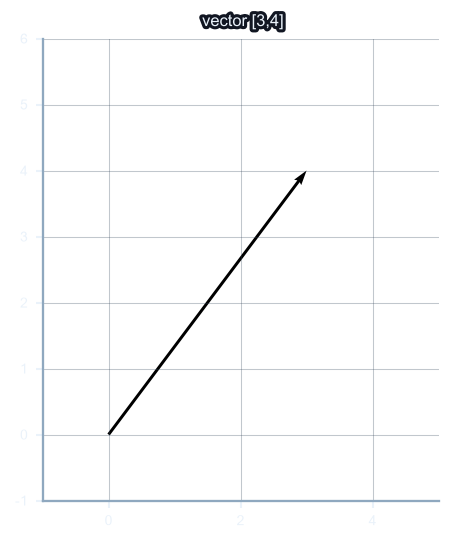

In [15]:
import matplotlib.pyplot as plt
v = np.array([3.0, 4.0])
plt.figure(figsize=(4,4))
plt.quiver(0,0, v[0], v[1], angles='xy', scale_units='xy', scale=1)
plt.xlim(-1,5); plt.ylim(-1,6); plt.grid(True, alpha=.3)
plt.gca().set_aspect('equal'); plt.title('vector [3,4]'); plt.show()

### 补一张对比图：负数缩放 = 转 180 度

前面推理路线里说过"`c < 0` 时方向反转"，但上面的图只画了 `[3, 4]` 一支箭头，没画反转后的样子。光看文字很难想象"转了180度"到底长什么样，下面直接把 `v=[3,4]` 和 `-v=[-3,-4]` 画在同一张图上对比：你会看到两支箭头方向正好相反、长度完全相同，像钟表的指针甩到了正对面。


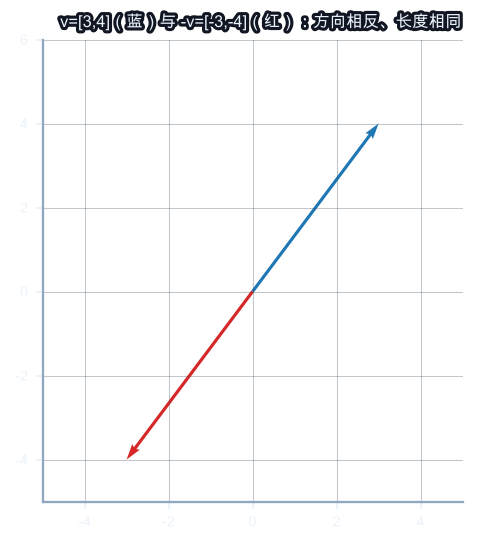

In [16]:
v = np.array([3.0, 4.0])
neg_v = -1 * v
plt.figure(figsize=(4,4))
plt.quiver(0,0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='tab:blue')
plt.quiver(0,0, neg_v[0], neg_v[1], angles='xy', scale_units='xy', scale=1, color='tab:red')
plt.xlim(-5,5); plt.ylim(-5,6); plt.grid(True, alpha=.3)
plt.gca().set_aspect('equal')
plt.title('v=[3,4]（蓝）与 -v=[-3,-4]（红）：方向相反、长度相同')
plt.show()


**🔗 Aurora 连接**：`aurora/audio/mfcc.py` 中的 `mfcc()` 函数
返回形状为 `(n_frames, 13)` 的矩阵，每一行是一帧音频的 13 维 MFCC 系数向量；
取其中一行（如 `coeffs[i]`，shape `(13,)`）再用 `scale(frame, gain)` 做逐元素缩放，
就是 Aurora 音量归一化步骤的数学本质（调音量 = 乘标量，不改变频谱形状）。
下一课点积（L10）会让你定量比较两帧 MFCC 向量的相似度——语音检索和注意力机制的底层操作。

### 踩坑提醒：`mfcc[i]` 和 `mfcc[i:i+1]` 不是一回事

上面说"取其中一行 `coeffs[i]`，shape 是 `(13,)`"——这里有个初学者很容易踩的坑：如果一不小心把 `mfcc[i]` 写成 `mfcc[i:i+1]`，两者装的数据看起来一样，形状（shape）却不一样，后续做矩阵运算时容易莫名其妙报错或结果不对。

打个比方：一个班级的点名册就像一个 `(n_frames, 13)` 矩阵，每一行是一个学生（向量）。"点名点到第 3 个学生"（对应 `mfcc[2]`）和"把点名册截出第 3 行、单独作为一份只有一行的小名册"（对应 `mfcc[2:3]`），虽然拿到的都是同一个学生的信息，但前者给你的是"这一个学生本人"（数据降了一维，直接是 `(13,)` 的向量），后者给你的还是"一份名册"，只是这份名册恰好只有一行（保留了二维，shape 是 `(1, 13)`）。

**记住这条规则**：方括号里写单个整数（如 `mfcc[2]`）→ 那一维被"吃掉"，维度减一；方括号里写切片（如 `mfcc[2:3]` 或 `mfcc[2, :]` 中的 `:`）→ 维度被保留。`mfcc[i, :]` 和 `mfcc[i]` 其实是等价的写法，都会降维；只有用范围切片 `i:i+1` 才会保留那个"只有一行"的二维形状。下面直接用一个简化的小矩阵验证三种写法的 shape 差异。


In [17]:
mfcc_like = np.array([[0.1, 0.2, 0.3],
                       [0.4, 0.5, 0.6],
                       [0.7, 0.8, 0.9]])   # 假装这是一个 (3帧, 3维) 的简化 MFCC 矩阵

row_index = mfcc_like[1]        # 整数索引：降一维 -> (3,)
row_slice = mfcc_like[1:2]      # 范围切片：保留二维 -> (1,3)
row_colon = mfcc_like[1, :]     # 等价于 mfcc_like[1]，同样降一维 -> (3,)

print('mfcc_like[1]    shape =', row_index.shape, '->', row_index)
print('mfcc_like[1:2]  shape =', row_slice.shape, '->', row_slice)
print('mfcc_like[1, :] shape =', row_colon.shape, '->', row_colon)
print('数值相同吗？', np.allclose(row_index, row_slice.flatten()))


mfcc_like[1]    shape = (3,) -> [0.4 0.5 0.6]
mfcc_like[1:2]  shape = (1, 3) -> [[0.4 0.5 0.6]]
mfcc_like[1, :] shape = (3,) -> [0.4 0.5 0.6]
数值相同吗？ True


## 🎨 图示：向量 = 带方向的箭头，缩放 = 改变长度

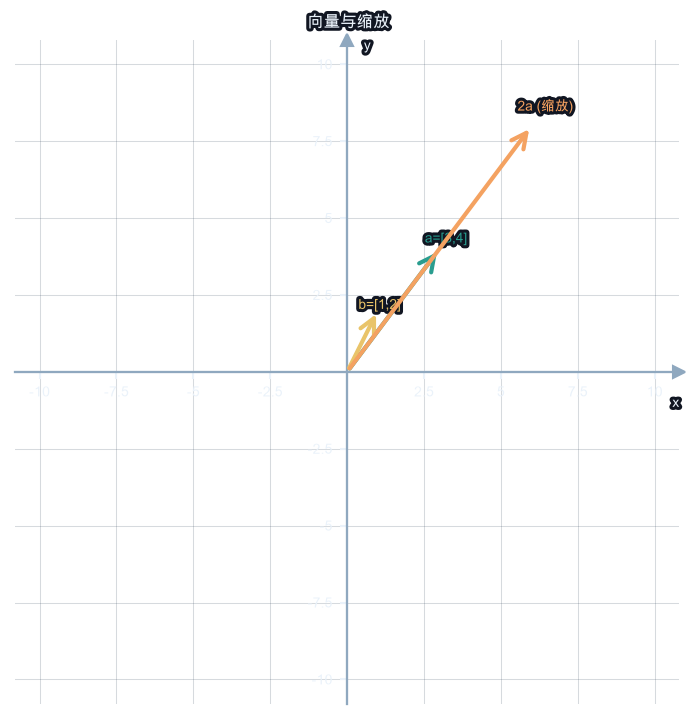

In [18]:
from aurora.laviz import style, arrows2d
style()
arrows2d([[3,4],[1,2],[6,8]], ['a=[3,4]','b=[1,2]','2a (缩放)'],
         title='向量与缩放');

### 先补一句直觉：`A @ v` 到底在干嘛？

矩阵作用在向量上的完整理论会留到 L12 详细展开，但既然接下来的代码马上就要用到 `A @ v`，这里先给一个能撑到下节课的直觉，不让它"悬空"。

还记得前面刚学过的：任意向量都能写成基向量的线性组合，比如 `v = v₁·e1 + v₂·e2`。矩阵 `A` 的每一列，其实就是在告诉你："原来的 e1、e2 被搬到哪里去了"。比如 `A = [[2,1],[0,1]]`，它的第一列 `[2,0]` 就是"新的 e1 落在哪"，第二列 `[1,1]` 就是"新的 e2 落在哪"。

于是 `A @ v` 在做的事情就是：先把 `v` 按线性组合拆开成 `v₁` 份 e1 加 `v₂` 份 e2，然后不再用原来的 e1、e2，而是换成"A 告诉你的新 e1、新 e2"，按同样的系数 `v₁`、`v₂` 重新拼一遍——也就是 `A @ v = v₁ · (A的第一列) + v₂ · (A的第二列)`。矩阵之所以能把向量"拉伸、旋转、切变"，本质上就是因为它在偷偷挪动基向量的位置，而任何向量都不过是基向量的线性组合，基向量一挪窝，组合出来的结果自然跟着变。下面直接验证这个等式成立，完整的"矩阵怎样决定拉伸方向、旋转角度、特征向量"会在 L12 里细讲。


In [19]:
A_demo = np.array([[2.0, 1.0], [0.0, 1.0]])
v_demo = np.array([1.0, 1.0])

lhs = A_demo @ v_demo
rhs = v_demo[0]*A_demo[:, 0] + v_demo[1]*A_demo[:, 1]   # 用 A 的两列做线性组合
print('A @ v            =', lhs)
print('v0*列0 + v1*列1   =', rhs)
print('两者相等：', np.allclose(lhs, rhs))


A @ v            = [3. 1.]
v0*列0 + v1*列1   = [3. 1.]
两者相等： True


In [20]:
A = np.array([[2.0, 1.0], [0.0, 1.0]])
probes = np.array([[1,0], [0,1], [1,1], [-1,2]], dtype=float)
print('矩阵 A 会怎样移动这些向量？')
for v in probes:
    out = A @ v
    print(f'{v} -> {out} | 长度 {np.linalg.norm(v):.2f} -> {np.linalg.norm(out):.2f}')


矩阵 A 会怎样移动这些向量？
[1. 0.] -> [2. 0.] | 长度 1.00 -> 2.00
[0. 1.] -> [1. 1.] | 长度 1.00 -> 1.41
[1. 1.] -> [3. 1.] | 长度 1.41 -> 3.16
[-1.  2.] -> [0. 2.] | 长度 2.24 -> 2.00


## 参数实验：只改一个旋钮

1. 把 `A[0][1]` 从 `1.0` 改成 `0.0`——矩阵变成对角矩阵，x 分量不再受 y 影响；验证：只有非对角元素才会让不同分量互相影响。
2. 把 `A[0][1]` 改成负数（如 `-2.0`），先手算 `v=[1, 1]` 的输出，再运行对照——负值会把 x 分量"拉向反方向"。
3. 把 `probes` 里一个向量换成 `[3.0, 4.0]`（norm = 5.0），观察矩阵对"长"向量的缩放倍率是否与对 `[1, 1]` 相同（提示：矩阵变换一般**不**保持 norm 不变，除非是正交矩阵）。

## 本课收束

现在可以用 `scale(v, c)` 对任意 numpy array 做逐元素缩放，输出 shape 与输入完全相同。这对应 Aurora `aurora/audio` 里的调音量操作，而向量加法对应混音——两个操作合起来覆盖了信号合成的底层逻辑。MFCC 特征提取最终把每帧压成一个 `(13,)` 向量，就是今天操作的对象形式。下一节点积会让你计算两个向量的相似度，这是特征匹配和注意力机制的基础运算。

## ✏️ 白板挑战：向量运算手算（目标 8 分钟）

盖上屏幕，纸上作答：

**问 1**：v = [3, 4]，c = 2.5，`scale(v, c)` = ?

**问 2**：a = [1.0, -0.5, 0.8]，b = [0.2, 0.7, -0.3]，`add_signals(a, b)` = ?

**问 3**：coeffs = [2.0, -1.0, 0.5]，vecs = [[1,0],[0,1],[2,2]]  
`linear_combination(coeffs, vecs)` = 2×[1,0] + (−1)×[0,1] + 0.5×[2,2] = ?

**问 4**：向量 [3, 4] 的 L2 范数（欧式长度）是多少？公式：`‖v‖ = √(v₁² + v₂²)` = ?

推导完成后运行下面格对答案。

In [21]:
# ✏️ 对答案格
import numpy as np

passed = []

# 问1：scale
v, c = np.array([3.0, 4.0]), 2.5
q1_expected = np.array([7.5, 10.0])
try:
    q1 = scale(v, c)
    assert np.allclose(q1, q1_expected, atol=1e-10), f"scale 结果 {q1} 与期望 {q1_expected} 不符"
    print(f"Q1 ✅  scale([3,4], 2.5) = {q1}")
    passed.append(1)
except (NotImplementedError, TypeError):
    print("⬜ Q1：请先实现 scale()，再运行对答案格")

# 问2：add_signals
a, b = np.array([1.0, -0.5, 0.8]), np.array([0.2, 0.7, -0.3])
q2_expected = np.array([1.2, 0.2, 0.5])
try:
    q2 = add_signals(a, b)
    assert np.allclose(q2, q2_expected, atol=1e-10)
    print(f"Q2 ✅  add_signals = {q2}")
    passed.append(2)
except (NotImplementedError, TypeError):
    print("⬜ Q2：请先实现 add_signals()，再运行对答案格")

# 问3：linear_combination
coeffs = [2.0, -1.0, 0.5]
vecs   = [np.array([1.0, 0.0]), np.array([0.0, 1.0]), np.array([2.0, 2.0])]
q3_expected = np.array([3.0, 0.0])
try:
    q3 = linear_combination(coeffs, vecs)
    assert np.allclose(q3, q3_expected, atol=1e-10)
    print(f"Q3 ✅  linear_combination = {q3}")
    passed.append(3)
except (NotImplementedError, TypeError):
    print("⬜ Q3：请先实现 linear_combination()，再运行对答案格")

if len(passed) == 3:
    print("\n🎉 白板挑战通过！向量三运算已内化。")


⬜ Q1：请先实现 scale()，再运行对答案格
⬜ Q2：请先实现 add_signals()，再运行对答案格
⬜ Q3：请先实现 linear_combination()，再运行对答案格


In [ ]:
# ✏️ 本课自评
l09_review = {
    "scale_implemented":             None,  # scale 实现并通过断言？True/False
    "add_signals_implemented":       None,  # add_signals 实现并通过断言？True/False
    "linear_combination_implemented": None, # linear_combination 实现并通过断言？True/False
    "vector_as_arrow_intuition":     None,  # 理解"向量=带方向的箭头"？True/False
    "whiteboard_passed":             None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l09_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l09_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L09 全部通关！进入 L10：点积与投影')

---

→ **下一课**　[L10 · 点积与投影](L10_dot_product.ipynb)

> 下节课将学习 **点积与投影**：a·b = |a||b|cosθ，为什么相似度 = 点积 ÷ 积范数。